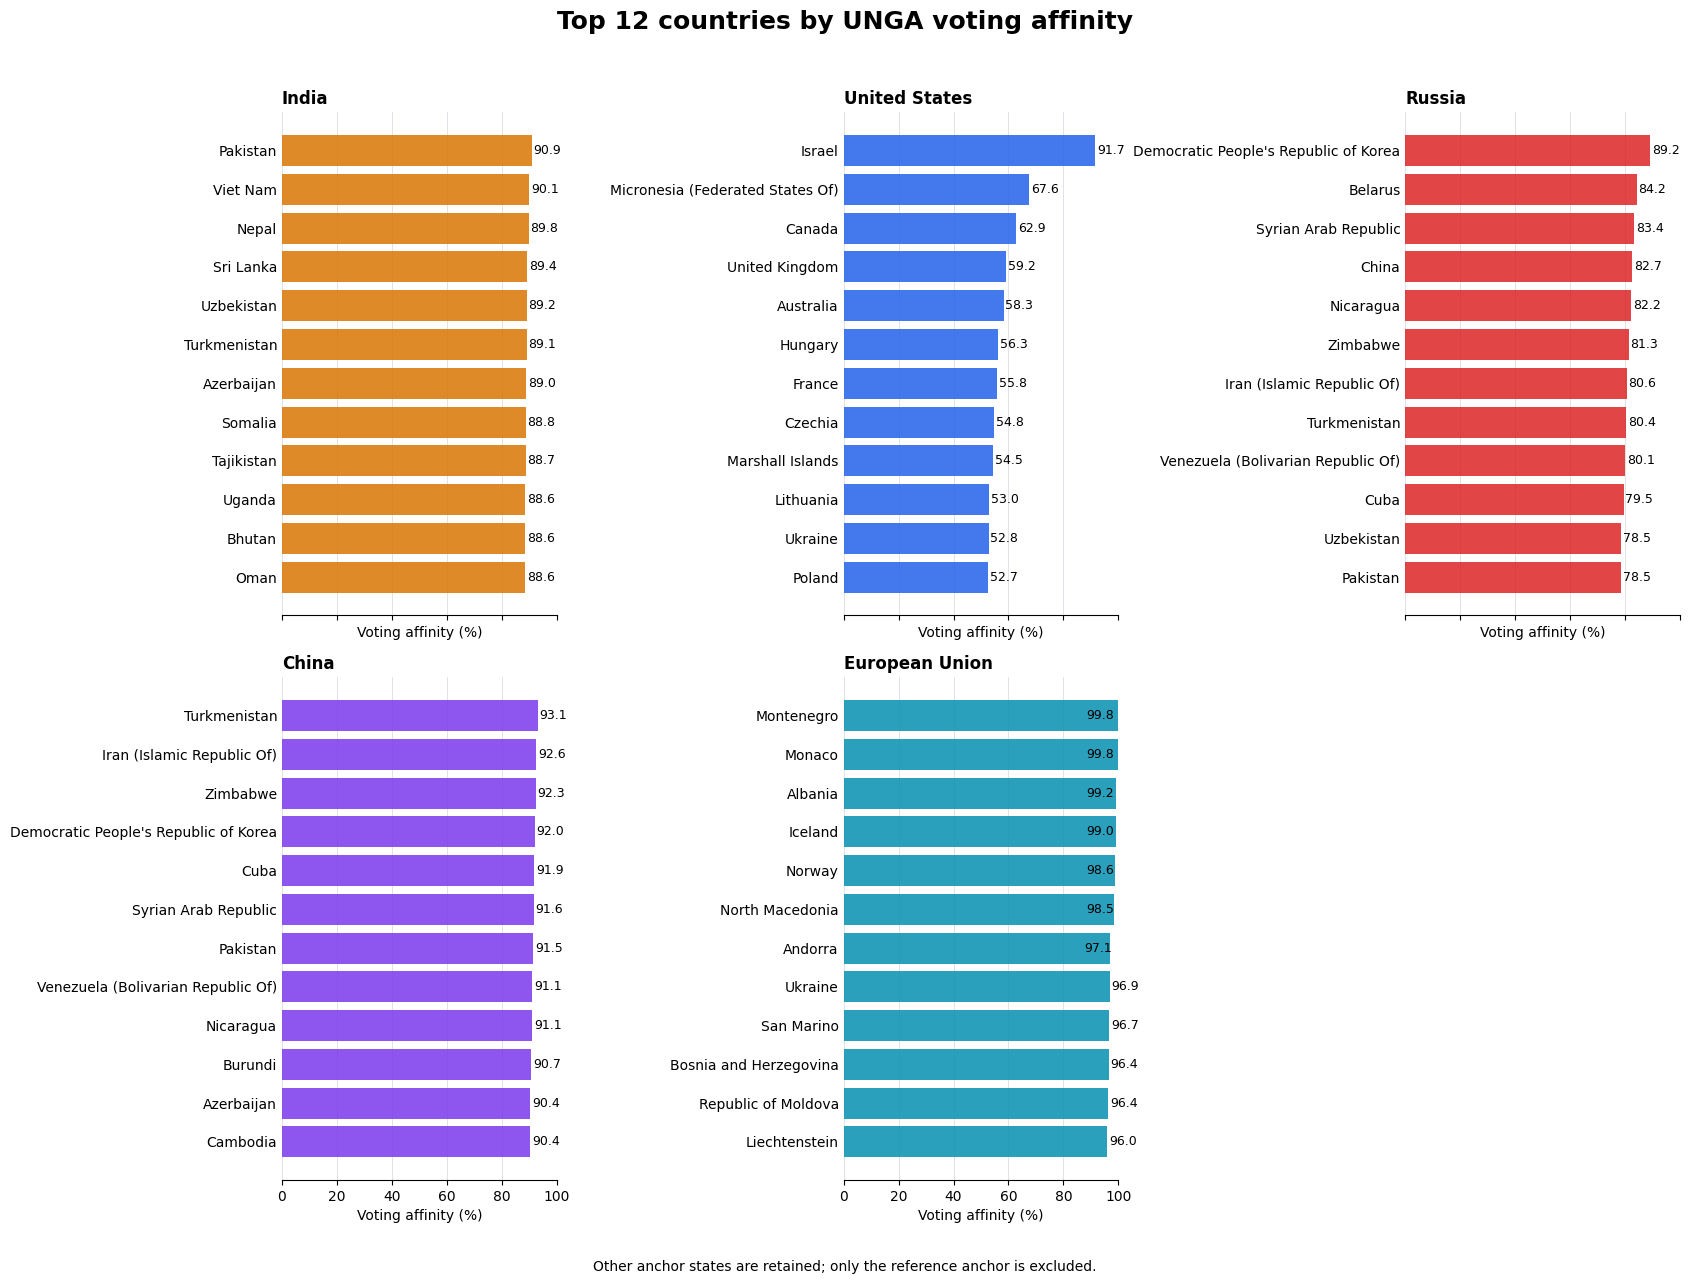

        anchor  rank                               country ms_code  affinity_pct  comparable_vote_n
         India     1                              Pakistan     PAK     90.913242               1095
         India     2                              Viet Nam     VNM     90.101758               1081
         India     3                                 Nepal     NPL     89.780018               1091
         India     4                             Sri Lanka     LKA     89.360731               1095
         India     5                            Uzbekistan     UZB     89.185111                994
         India     6                          Turkmenistan     TKM     89.076723                769
         India     7                            Azerbaijan     AZE     89.010417                960
         India     8                               Somalia     SOM     88.777372                548
         India     9                            Tajikistan     TJK     88.658777               1014


In [4]:
"""Rank and plot the 12 closest UNGA voting partners of five anchor states.

Required input in the same folder:
    2026_02_06_ga_voting.csv

The analysis covers 2015-2025. Other anchor states remain eligible for each
ranking; only the reference anchor itself is removed. For the European Union,
all EU27 member states are treated as the reference and therefore removed.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


VOTES_FILE = Path("2026_02_06_ga_voting.csv")
TOP_N = 12
MIN_COMPARABLE_VOTES = 30

EU27 = set(
    "AUT BEL BGR HRV CYP CZE DNK EST FIN FRA DEU GRC HUN IRL ITA LVA LTU "
    "LUX MLT NLD POL PRT ROU SVK SVN ESP SWE".split()
)

SELF_CODES = {
    "India": {"IND"},
    "United States": {"USA"},
    "Russia": {"RUS"},
    "China": {"CHN"},
    "European Union": EU27,
}

ANCHOR_COLORS = {
    "India": "#D97706",
    "United States": "#2563EB",
    "Russia": "#DC2626",
    "China": "#7C3AED",
    "European Union": "#0891B2",
}


# Read valid UNGA votes from the analysis period.
votes = pd.read_csv(
    VOTES_FILE,
    usecols=["undl_id", "ms_code", "ms_name", "ms_vote", "date"],
    low_memory=False,
)
votes["date"] = pd.to_datetime(votes["date"])
votes = votes[votes["date"].between("2015-01-01", "2025-12-31")]
votes = votes[votes["ms_vote"].isin(["Y", "N", "A"])].copy()

latest_names = (
    votes.sort_values("date")
    .drop_duplicates("ms_code", keep="last")
    .set_index("ms_code")["ms_name"]
    .to_dict()
)


def display_name(name):
    """Convert uppercase UN names into readable chart labels."""
    name = str(name).title().replace("'S", "'s")
    for word in [" Of ", " And ", " The "]:
        name = name.replace(word, word.lower())
    return name


latest_names = {code: display_name(name) for code, name in latest_names.items()}


def calculate_affinity(reference_votes):
    """Score exact agreement as 1, one abstention as 0.5, opposition as 0."""
    reference_votes = reference_votes[["undl_id", "reference_vote"]].dropna()
    pairs = votes[["undl_id", "ms_code", "ms_vote"]].merge(
        reference_votes, on="undl_id"
    )

    same_vote = pairs["ms_vote"].eq(pairs["reference_vote"])
    one_abstention = pairs["ms_vote"].eq("A") != pairs["reference_vote"].eq("A")
    pairs["score"] = np.select(
        [same_vote, one_abstention], [1.0, 0.5], default=0.0
    )

    affinity = (
        pairs.groupby("ms_code")["score"]
        .agg(affinity_pct=lambda values: values.mean() * 100,
             comparable_vote_n="size")
        .reset_index()
    )
    return affinity[affinity["comparable_vote_n"] >= MIN_COMPARABLE_VOTES]


# India is compared with every resolution on which India cast a valid vote.
india_reference = votes[votes["ms_code"].eq("IND")][["undl_id", "ms_vote"]]
india_reference = india_reference.rename(columns={"ms_vote": "reference_vote"})


# Construct a cohesive EU position: at least 20 EU members must vote and at
# least 80% of participating EU members must choose the same position.
eu_counts = (
    votes[votes["ms_code"].isin(EU27)]
    .groupby(["undl_id", "ms_vote"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Y", "N", "A"], fill_value=0)
)
eu_participants = eu_counts.sum(axis=1)
eu_mode = eu_counts.idxmax(axis=1)
eu_cohesion = eu_counts.max(axis=1) / eu_participants
eu_reference = pd.DataFrame(
    {
        "undl_id": eu_counts.index,
        "EU": eu_mode.where((eu_participants >= 20) & (eu_cohesion >= 0.80)),
    }
).reset_index(drop=True)


# For the US, Russia, China, and EU, retain resolutions on which at least two
# anchor positions differ. This follows the primary anchor-affinity analysis.
individual_anchors = (
    votes[votes["ms_code"].isin(["USA", "RUS", "CHN"])]
    .pivot(index="undl_id", columns="ms_code", values="ms_vote")
    .reset_index()
)
anchor_votes = individual_anchors.merge(eu_reference, on="undl_id", how="outer")
anchor_columns = ["USA", "RUS", "CHN", "EU"]
anchor_votes = anchor_votes[anchor_votes[anchor_columns].nunique(axis=1) >= 2]

reference_votes = {
    "India": india_reference,
    "United States": anchor_votes[["undl_id", "USA"]].rename(
        columns={"USA": "reference_vote"}
    ),
    "Russia": anchor_votes[["undl_id", "RUS"]].rename(
        columns={"RUS": "reference_vote"}
    ),
    "China": anchor_votes[["undl_id", "CHN"]].rename(
        columns={"CHN": "reference_vote"}
    ),
    "European Union": anchor_votes[["undl_id", "EU"]].rename(
        columns={"EU": "reference_vote"}
    ),
}


# Rank partners. Other anchor states are retained; only the reference itself
# is excluded from its own ranking.
tables = []
for anchor, reference in reference_votes.items():
    ranked = calculate_affinity(reference)
    ranked = ranked[~ranked["ms_code"].isin(SELF_CODES[anchor])].copy()
    ranked["country"] = ranked["ms_code"].map(latest_names)
    ranked = ranked.sort_values(
        ["affinity_pct", "comparable_vote_n", "country"],
        ascending=[False, False, True],
    ).head(TOP_N)
    ranked.insert(0, "anchor", anchor)
    ranked.insert(1, "rank", range(1, len(ranked) + 1))
    tables.append(ranked)

top_partners = pd.concat(tables, ignore_index=True)
top_partners = top_partners[
    [
        "anchor",
        "rank",
        "country",
        "ms_code",
        "affinity_pct",
        "comparable_vote_n",
    ]
]
top_partners.to_csv("top_12_voting_partners.csv", index=False)


# Visualization: five comparable horizontal rankings on a common 0-100 scale.
fig, axes = plt.subplots(2, 3, figsize=(17, 13), sharex=True)
axes = axes.ravel()

for ax, anchor in zip(axes, reference_votes):
    chart = top_partners[top_partners["anchor"].eq(anchor)].sort_values(
        "affinity_pct"
    )
    bars = ax.barh(
        chart["country"],
        chart["affinity_pct"],
        color=ANCHOR_COLORS[anchor],
        alpha=0.86,
    )
    ax.set_title(anchor, fontweight="bold", loc="left")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Voting affinity (%)")
    ax.grid(axis="x", color="#D1D5DB", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)

    for bar, value in zip(bars, chart["affinity_pct"]):
        ax.text(
            min(value + 0.6, 98.5),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}",
            va="center",
            ha="right" if value > 97 else "left",
            fontsize=9,
        )

axes[-1].axis("off")
fig.suptitle(
    "Top 12 countries by UNGA voting affinity",
    fontsize=18,
    fontweight="bold",
)
fig.text(
    0.5,
    0.01,
    "Other anchor states are retained; only the reference anchor is excluded.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=[0, 0.035, 1, 0.96])
fig.savefig("top_12_voting_partners.png", dpi=300, bbox_inches="tight")
plt.show()

print(top_partners.to_string(index=False))
print("\nSaved top_12_voting_partners.csv")
print("Saved top_12_voting_partners.png")